In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [2]:
x_train=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
x_test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

In [3]:
dummy_x=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
dummy_x_test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

In [4]:
print(x_train.shape)
print(x_test.shape)

(594194, 21)
(254655, 20)


In [5]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [6]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

In [7]:
y_train=x_train['Churn']
x_train=x_train.drop(columns=['Churn'])

In [8]:
x_train=x_train.drop(columns=['id'])

In [9]:
x_test=x_test.drop(columns=['id'])

In [10]:
y_train.shape

(594194,)

In [11]:
x_test.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [12]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20


In [13]:
def uniq(a):
    print(pd.unique(a))

In [14]:
for i in range(x_train.shape[1]):
    uniq(x_train.iloc[:,i])

['Male' 'Female']
[0 1]
['Yes' 'No']
['Yes' 'No']
[29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]
['Yes' 'No']
['No' 'Yes' 'No phone service']
['DSL' 'Fiber optic' 'No']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['One year' 'Two year' 'Month-to-month']
['Yes' 'No']
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
[ 60.1   69.5  100.4  ...  18.45 112.05  46.15]
[1653.85 3778.2  5841.35 ... 1478.9  1284.75 5460.7 ]


In [15]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [16]:
x_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [17]:
x_train.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20


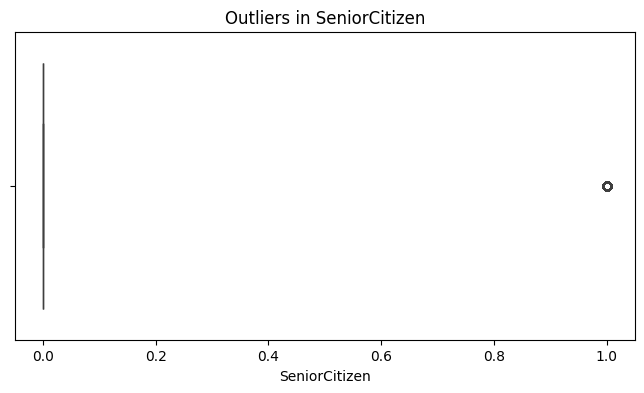

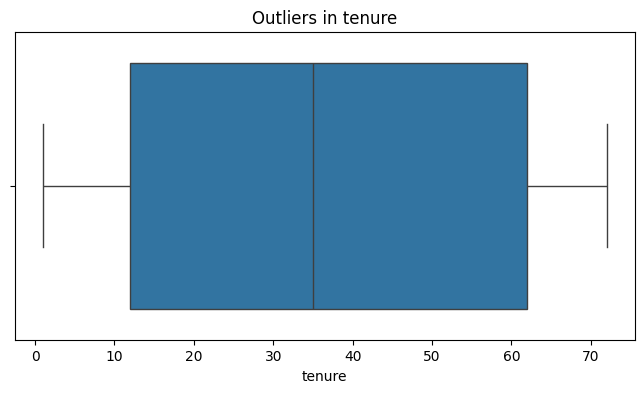

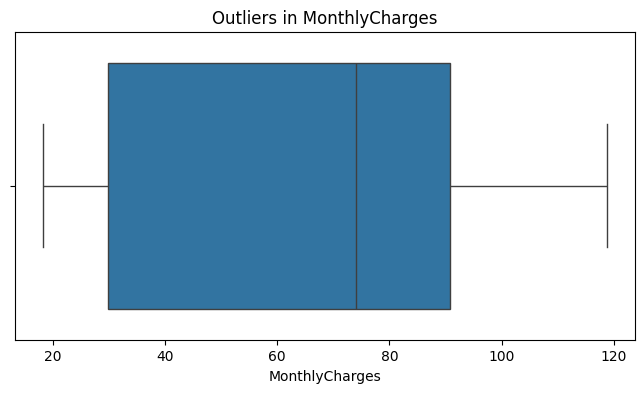

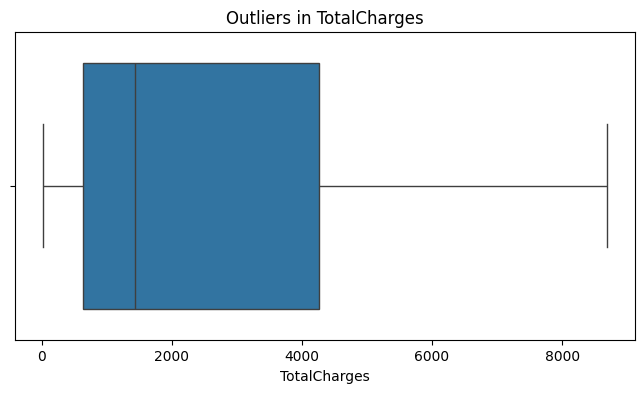

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_cols = x_train.select_dtypes(include=['number']).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=x_train[col])
    plt.title(f'Outliers in {col}')
    plt.show()

In [19]:
num_cols=x_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols=x_train.select_dtypes(include=['object','category']).columns.tolist()

In [20]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_cols)
    ]
)
preprocessor.set_output(transform="pandas")
x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.transform(x_test)

In [21]:
x_train

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.358885,-0.302342,-0.185604,-0.357076,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.358885,0.854793,0.116964,0.545399,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.358885,0.854793,1.111575,1.421875,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.358885,-1.419575,0.123402,-1.029637,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.358885,-1.419575,0.147543,-1.029743,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,-0.358885,0.814892,1.019839,1.260166,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
594190,-0.358885,1.413410,0.839586,1.821550,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
594191,-0.358885,1.413410,-1.334717,-0.264443,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
594192,-0.358885,-0.182638,0.648067,0.149888,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [22]:
y_train=y_train.map({'Yes':1,'No':0})

In [23]:
# from sklearn.linear_model import LogisticRegression
# lgr=LogisticRegression()
# lgr.fit(x_train,y_train)

In [24]:
# y_pred=lgr.predict(x_test)

In [25]:
# y_pred

In [26]:
# from xgboost import XGBClassifier
# xgb=XGBClassifier()
# xgb.fit(x_train,y_train)
# y_xgb_pred=xgb.predict(x_test)

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization,Input
model=Sequential(
    [   Input(shape=(x_train.shape[1],)),
        Dense(128,activation='relu'),
        BatchNormalization(),Dropout(0.3),
        Dense(64,activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1,activation='sigmoid')
    ]
)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

2026-03-18 18:23:19.590947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773858199.850036      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773858199.927339      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773858200.588705      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773858200.588743      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773858200.588747      17 computation_placer.cc:177] computation placer alr

In [28]:
from tensorflow.keras.callbacks import EarlyStopping
ears=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


In [29]:
model.fit(x_train,y_train,epochs=500,validation_split=0.2,callbacks=[ears])

Epoch 1/500
14855/14855 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step - accuracy: 0.8403 - loss: 0.3426 - val_accuracy: 0.8548 - val_loss: 0.3083
Epoch 2/500
14855/14855 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - accuracy: 0.8523 - loss: 0.3180 - val_accuracy: 0.8557 - val_loss: 0.3069
Epoch 3/500
14855/14855 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 0.8543 - loss: 0.3144 - val_accuracy: 0.8557 - val_loss: 0.3071
Epoch 4/500
14855/14855 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.8539 - loss: 0.3148 - val_accuracy: 0.8562 - val_loss: 0.3056
Epoch 5/500
14855/14855 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.8553 - loss: 0.3111 - val_accuracy: 0.8567 - val_loss: 0.3055
Epoch 6/500
14855/14855 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 0.8543 - loss: 0.3130 - val_accuracy: 0.8562 - val_loss: 0.3059
Epoch 7/500
14855/14855 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.8548 - loss: 0.3122 - val_accuracy: 0.8563 - val_loss: 0.3052
Epoch 8/500
14855/14855 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - ac

In [30]:
y_pred_nn=model.predict(x_test)
y_final=(y_pred_nn>0.5).astype(int)

7958/7958 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


In [31]:
comp_test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")
id=comp_test['id']
submission_nn=pd.DataFrame({
    "id":id,
    "Churn":y_final.flatten()
})
submission_nn.to_csv('submission_nn.csv',index=False)
print("Done")

Done


In [32]:
# comp_test=pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")
# id=comp_test['id']
# submission_lr=pd.DataFrame({
#     "id":id,
#     "Churn":y_pred
# })
# submission_lr.to_csv('submission_lr.csv',index=False)
# print("Done")

In [33]:
# submission_xgb=pd.DataFrame({
#     "id":id,
#     "Churn":y_xgb_pred
# })
# submission_lr.to_csv('submission_xgb.csv',index=False)
# print("Done")